In [8]:
import os
print(os.listdir())

['.config', 'train.csv', 'sample_data']


Imports done ✅
Shape: (8337, 202)

Target distribution:
target
0    7512
1     825
Name: count, dtype: int64

Class imbalance ratio: 9.1:1
Train shape: (6669, 200)
Val shape: (1668, 200)
Missing values remaining: 0
Scaling done ✅
📊 Baseline Results:
Recall:    0.2606  ← target: 0.88+
F1 Score:  0.3789
Accuracy:  0.9155
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1503
           1       0.69      0.26      0.38       165

    accuracy                           0.92      1668
   macro avg       0.81      0.62      0.67      1668
weighted avg       0.90      0.92      0.90      1668

Feature stats:
            mean       std      min      max
var_0  10.676439  3.031953   1.3350  19.2893
var_1  -1.663465  4.073489 -13.4227   8.4998
var_2  10.696799  2.636732   3.3090  18.3477
var_3   6.817679  2.058622   1.1541  12.9773
var_4  11.093312  1.628930   6.0315  15.3664
var_5  -5.042800  7.825941 -27.6879  15.6365
var_6   5.401416  0.86

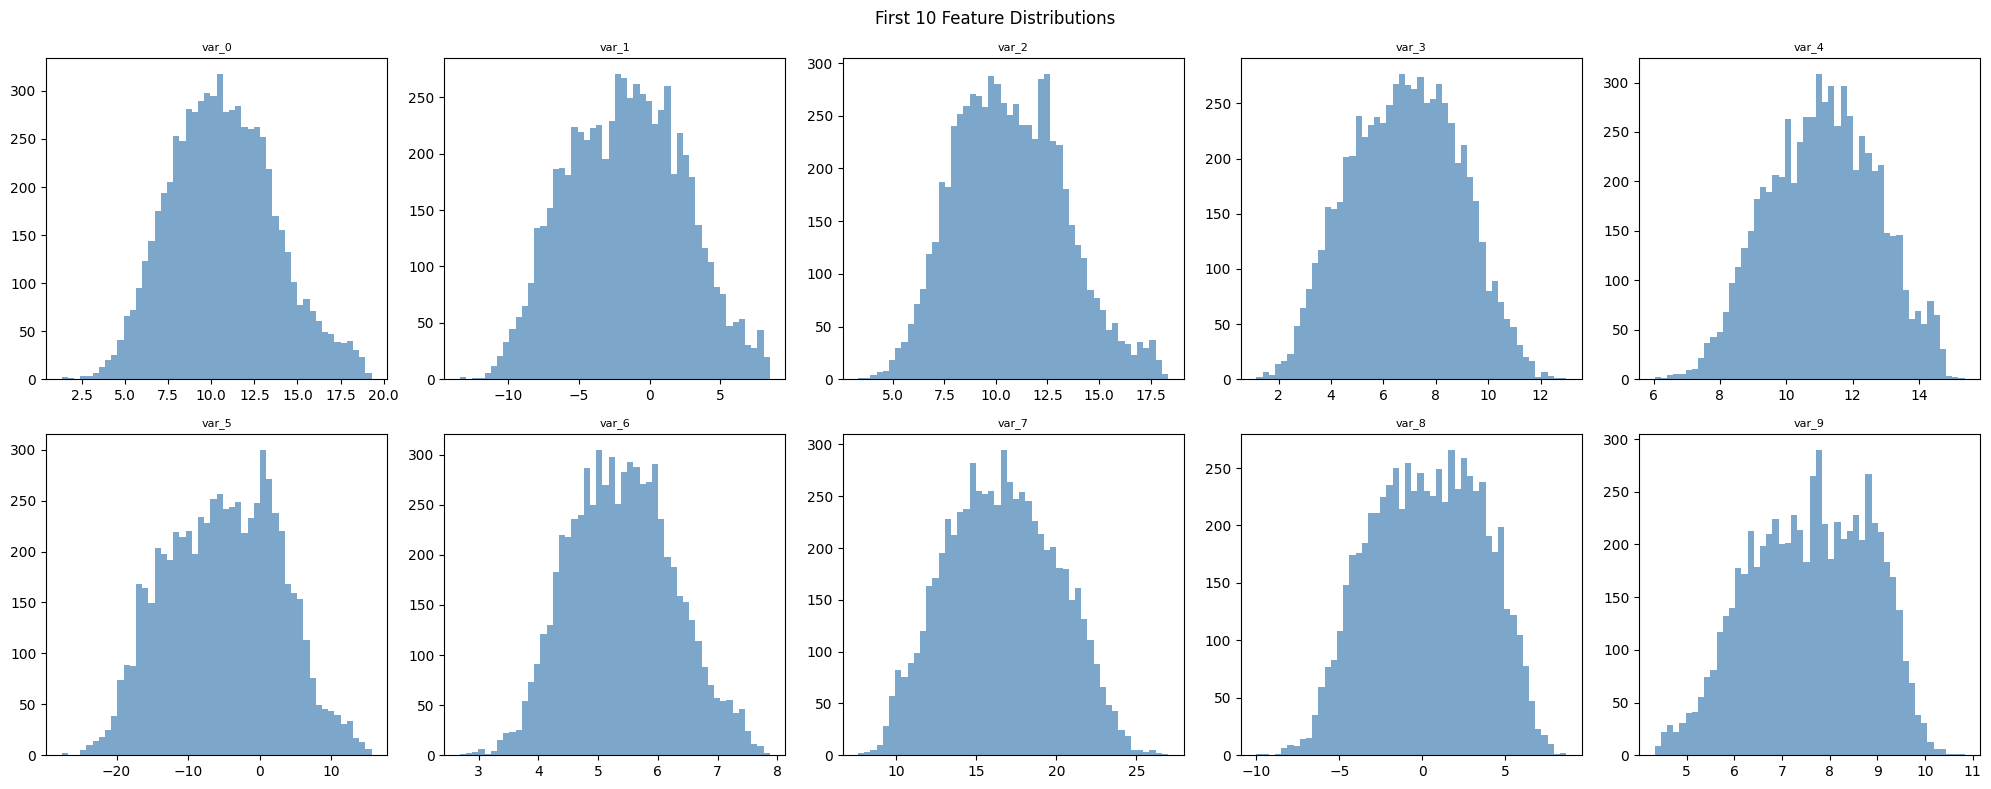


Mean feature values by class:
            var_0     var_1      var_2     var_3      var_4
target                                                     
0       10.635108 -1.757868  10.640481  6.790228  11.078954
1       11.052731 -0.803967  11.209547  7.067611  11.224026
Features before engineering: 200
Features after engineering:  212
New features added ✅
Scaling done ✅
📊 After Feature Engineering:
Recall:    0.2788
F1 Score:  0.3966
Accuracy:  0.9161
Before SMOTE: {0: 6009, 1: 660}
After SMOTE:  {0: 6009, 1: 6009}

📊 After SMOTE:
Recall:    0.7091
F1 Score:  0.4142
Accuracy:  0.8016
📊 Hyperparameter Tuning Results:
C        Penalty    Recall       F1
----------------------------------------
0.01     l2         0.7091   0.4186
0.1      l2         0.7091   0.4142
1.0      l2         0.7091   0.4142
10.0     l2         0.7091   0.4142
0.01     l1         0.6667   0.3642
0.1      l1         0.7030   0.4165
1.0      l1         0.7091   0.4134

🏆 Best config: {'C': 0.01, 'penalty': 'l2', 'c

In [13]:
# ============================================================
# FEATURE ENGINEERING CHALLENGE — Santander Dataset
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (recall_score, f1_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print("Imports done ✅")

# ── Block 2: Load Data ─────────────────────────────────────
# Directly read train.csv from the environment (no upload needed)
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nClass imbalance ratio: {df['target'].value_counts()[0] / df['target'].value_counts()[1]:.1f}:1")

# ── Block 3: Prepare Baseline ─────────────────────────────
# Drop ID column — not useful for prediction
df = df.drop('ID_code', axis=1)

# Handle missing values (fill NaNs with the mean of each column)
df = df.fillna(df.mean())

X = df.drop('target', axis=1)
y = df['target']

# Split — stratify to keep class ratio in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Missing values remaining:", df.isna().sum().sum())
print("Scaling done ✅")

# ── Block 4: Baseline Model ────────────────────────────────
baseline_lr = LogisticRegression(random_state=42, max_iter=1000)
baseline_lr.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_lr.predict(X_val_scaled)

print("📊 Baseline Results:")
print(f"Recall:    {recall_score(y_val, y_pred_baseline):.4f}  ← target: 0.88+")
print(f"F1 Score:  {f1_score(y_val, y_pred_baseline):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_baseline):.4f}")
print(classification_report(y_val, y_pred_baseline))

# ── Block 5: EDA — Understand the Dataset ─────────────────
print("Feature stats:")
print(X_train.describe().T[['mean', 'std', 'min', 'max']].head(10))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    ax.hist(X_train.iloc[:, i], bins=50, color='steelblue', alpha=0.7)
    ax.set_title(X_train.columns[i], fontsize=8)
plt.suptitle('First 10 Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

df_train = pd.DataFrame(X_train, columns=X.columns)
df_train['target'] = y_train.values
class_means = df_train.groupby('target').mean()
print("\nMean feature values by class:")
print(class_means.iloc[:, :5])

# ── Block 6: Feature Engineering ──────────────────────────
def engineer_features(X_df):
    X_new = X_df.copy()
    X_new['row_mean'] = X_df.mean(axis=1)
    X_new['row_std'] = X_df.std(axis=1)
    X_new['row_max'] = X_df.max(axis=1)
    X_new['row_min'] = X_df.min(axis=1)
    X_new['row_median'] = X_df.median(axis=1)
    X_new['row_skew'] = X_df.skew(axis=1)
    X_new['row_kurt'] = X_df.kurt(axis=1)
    X_new['positive_count'] = (X_df > 0).sum(axis=1)
    X_new['negative_count'] = (X_df < 0).sum(axis=1)
    X_new['zero_count'] = (X_df == 0).sum(axis=1)
    X_new['row_range'] = X_df.max(axis=1) - X_df.min(axis=1)
    X_new['row_abs_sum'] = X_df.abs().sum(axis=1)
    return X_new

X_train_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)

print(f"Features before engineering: {X_train.shape[1]}")
print(f"Features after engineering:  {X_train_fe.shape[1]}")
print("New features added ✅")

# ── Block 7: Scale Engineered Features ────────────────────
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_val_fe_scaled = scaler_fe.transform(X_val_fe)
print("Scaling done ✅")

# ── Block 8: Model with Engineered Features ────────────────
lr_fe = LogisticRegression(random_state=42, max_iter=1000)
lr_fe.fit(X_train_fe_scaled, y_train)
y_pred_fe = lr_fe.predict(X_val_fe_scaled)

print("📊 After Feature Engineering:")
print(f"Recall:    {recall_score(y_val, y_pred_fe):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_fe):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_fe):.4f}")

# ── Block 9: Handle Class Imbalance with SMOTE ────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_fe_scaled, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_smote).value_counts().to_dict())

lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_val_fe_scaled)

print("\n📊 After SMOTE:")
print(f"Recall:    {recall_score(y_val, y_pred_smote):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_smote):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_smote):.4f}")

# ── Block 10: Tune LogReg Hyperparameters ─────────────────
configs = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': 'balanced'},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced'},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced'},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': 'balanced'},
    {'C': 0.01,  'penalty': 'l1', 'class_weight': 'balanced', 'solver': 'liblinear'},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': 'balanced', 'solver': 'liblinear'},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': 'balanced', 'solver': 'liblinear'},
]

print("📊 Hyperparameter Tuning Results:")
print(f"{'C':<8} {'Penalty':<8} {'Recall':>8} {'F1':>8}")
print("-" * 40)

best_recall = 0
best_config = None

for config in configs:
    lr_temp = LogisticRegression(random_state=42, max_iter=1000, **config)
    lr_temp.fit(X_train_smote, y_train_smote)
    y_pred_temp = lr_temp.predict(X_val_fe_scaled)
    rec = recall_score(y_val, y_pred_temp)
    f1 = f1_score(y_val, y_pred_temp)
    print(f"{config['C']:<8} {config['penalty']:<8} {rec:>8.4f} {f1:>8.4f}")
    if rec > best_recall:
        best_recall = rec
        best_config = config

print(f"\n🏆 Best config: {best_config}")
print(f"🏆 Best Recall: {best_recall:.4f}")

# —— Block 11: Final Model with Best Config —————————————————
final_lr = LogisticRegression(random_state=42, max_iter=1000, **best_config)
final_lr.fit(X_train_smote, y_train_smote)
y_pred_final = final_lr.predict(X_val_fe_scaled)

print("=" * 50)
print("📊 FINAL MODEL RESULTS:")
print("=" * 50)
print(f"Recall:    {recall_score(y_val, y_pred_final):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_final):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_val, y_pred_final))